In [3]:
import pandas as pd 


In [6]:
df = pd.read_csv("maisons_taiwan.csv")
df.head()

,date,age,metro,epicerie,latitude,longitude,prix
0,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   date       414 non-null    float64
 1   age        414 non-null    float64
 2   metro      414 non-null    float64
 3   epicerie   414 non-null    int64  
 4   latitude   414 non-null    float64
 5   longitude  414 non-null    float64
 6   prix       414 non-null    float64
dtypes: float64(6), int64(1)
memory usage: 22.8 KB


In [8]:
df.describe()

,date,age,metro,epicerie,latitude,longitude,prix
count,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000
mean,2013.148971,17.712560,1083.885689,4.094203,24.969030,121.533361,37.980193
std,0.281967,11.392485,1262.109595,2.945562,0.012410,0.015347,13.606488
min,2012.667000,0.000000,23.382840,0.000000,24.932070,121.473530,7.600000
25%,2012.917000,9.025000,289.324800,1.000000,24.963000,121.528085,27.700000
50%,2013.167000,16.100000,492.231300,4.000000,24.971100,121.538630,38.450000
75%,2013.417000,28.150000,1454.279000,6.000000,24.977455,121.543305,46.600000
max,2013.583000,43.800000,6488.021000,10.000000,25.014590,121.566270,117.500000


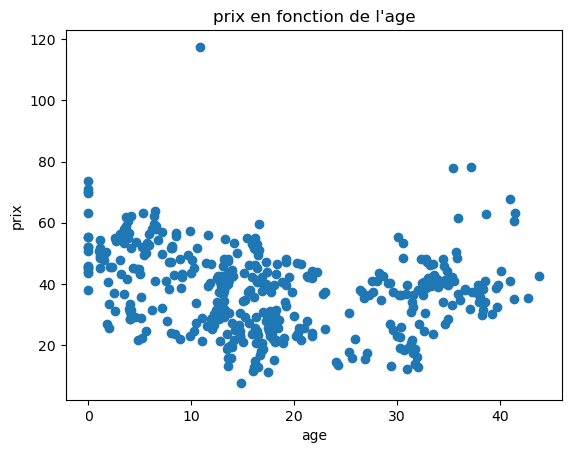

In [ ]:
#visulaisation 
import matplotlib.pyplot as plt 
plt.scatter(df["age"],df["prix"])
plt.xlabel("age")
plt.ylabel("prix")
plt.title("prix en fonction de l'age")
plt.show()

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
import numpy as np

In [13]:
x = df[["age"]]
y = df["prix"]

In [16]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [18]:
model = LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [ ]:
#
model.coef_

array([-0.25978378])

In [ ]:
#
model.intercept_

42.88289629775735

In [25]:
y_pred =model.predict(x_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

RMSE: 12.853214192676935


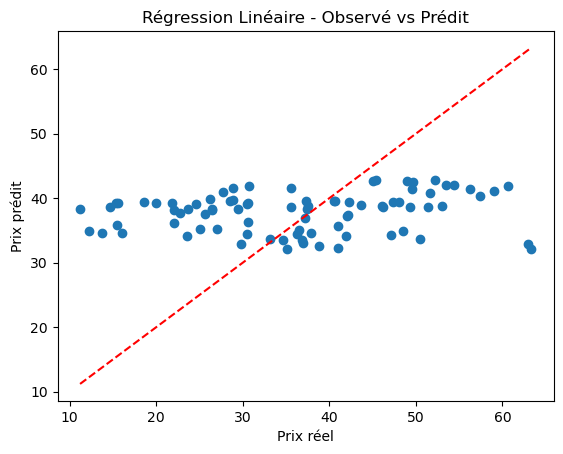

In [26]:
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()],
[y_test.min(), y_test.max()], "r--")
plt.xlabel("Prix réel")
plt.ylabel("Prix prédit")
plt.title("Régression Linéaire - Observé vs Prédit")
plt.show()

##Regression multiple


In [32]:


x = df[["age",'metro', 'epicerie']]
y = df["prix"]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(x_train,y_train)

model.coef_
model.intercept_

43.51488014404391

##Regression polynomiale

In [35]:
from sklearn.preprocessing import PolynomialFeatures
x.shape
poly = PolynomialFeatures(degree=2, include_bias= False)
x_poly= poly.fit_transform(x)
x_poly.shape

(414, 9)

In [2]:
x_train_poly, x_test_poly, y_train_poly,y_test_poly = train_test_split(
    x_poly, y, test_size=0.2, random_state=42
)


model_poly = LinearRegression()
model_poly.fit(x_train_poly, y_train_poly)
y_pred_poly = model_poly.predict(x_test_poly)

mse_poly = mean_squared_error(y_test_poly, y_pred_poly)
r2_poly = r2_score(y_test_poly, y_pred_poly)

NameError: name 'train_test_split' is not defined